In [49]:
%load_ext autoreload
%autoreload 2
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

import numpy as np
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, KFold

import matplotlib.pyplot as plt
import scanpy as sc
import anndata
import sys 
sys.path.append('/home/shuonan.chen/scratch_shuonan/code/LCNE_transcriptomics/code/')
import plotting,utils, processing
import pickle

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [50]:
# load data 
filename = '/home/shuonan.chen/scratch_shuonan/scripts/Pons_MERFISH/gene_to_loc_predict/data/data_loc_to_gene.pkl'
alldata = pickle.load(open(filename,'rb'))
locals().update(alldata)
input_dim = X_train.shape[1]

In [51]:
X_train.max(),X_train.min()

(np.float32(41.855026), np.float32(-4.0710635))

In [67]:
num_epochs = 1000
lr_grid    = [1e-2, 1e-3,1e-4]
hidden_dim = 1000
batch_size = 64*12


In [68]:
def make_loader(X, y, shuffle=True):
    tx = torch.from_numpy(X.astype(np.float32))
    ty = torch.from_numpy(y.astype(np.float32))
    ds = TensorDataset(tx, ty)
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle)

train_loader = make_loader(X_train, y_train, shuffle=True)
val_loader   = make_loader(X_val,   y_val,   shuffle=False)
test_loader  = make_loader(X_test,  y_test,  shuffle=False)


# MLP

In [69]:


class TwoLayerMLP(nn.Module):
    def __init__(self, in_dim, hid_dim, out_dim=3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hid_dim),
            nn.ReLU(),
            nn.Linear(hid_dim, hid_dim),
            nn.ReLU(),
            nn.Linear(hid_dim, out_dim)
        )
    def forward(self, x):
        return self.net(x)
    

### sweep

LR=0.01, VAL SET mse = 0.005278, R² = -0.020139256492257118
LR=0.001, VAL SET mse = 0.003869, R² = 0.22977757453918457
LR=0.0001, VAL SET mse = 0.004271, R² = 0.09831345081329346


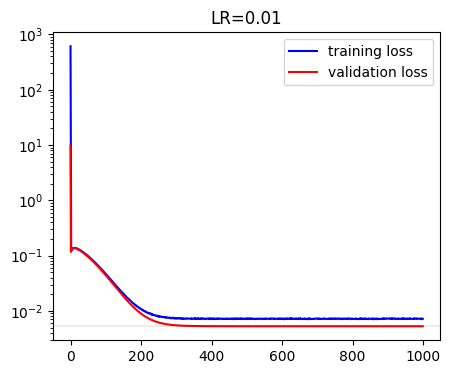

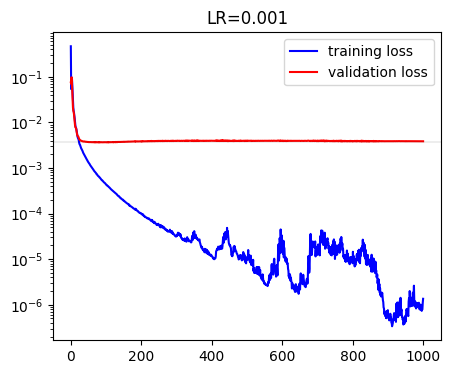

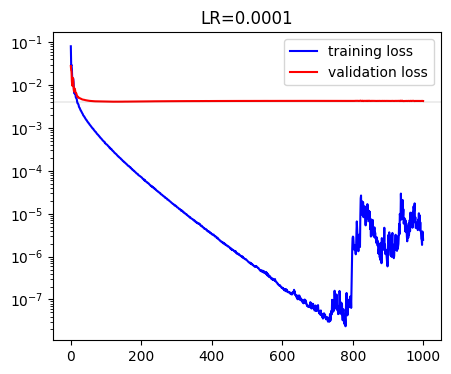

In [70]:
val_mse_per_lr = {}
for lr in lr_grid:
    model     = TwoLayerMLP(input_dim, hidden_dim)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()

    # training loop    
    train_loss = []
    val_loss = []
    for epoch in range(num_epochs):
        model.train()
        train_losses = []
        for xb, yb in train_loader:
            optimizer.zero_grad()
            preds = model(xb)
            loss  = criterion(preds, yb)
            loss.backward()
            train_losses.append(loss.item())
            optimizer.step()
        train_loss.append(np.mean(train_losses))
        
        model.eval()
        val_losses = []
        all_preds, all_targets = [], []
        with torch.no_grad():
            for xb, yb in val_loader:
                p = model(xb)
                all_preds.append(p.numpy())
                all_targets.append(yb.numpy())
                loss  = criterion(p, yb)
                val_losses.append(loss.item())        
            val_loss.append(np.mean(val_losses))    
        all_preds   = np.vstack(all_preds)
        all_targets = np.vstack(all_targets)
    
    # use the last epoch results to evaluate
    mse_val = mean_squared_error(all_targets, all_preds)
    r2_val  = r2_score(all_targets, all_preds)
    print(f"LR={lr}, VAL SET mse = {mse_val:.6f}, R² = {r2_val}")
        
    plt.figure(figsize = (5,4))
    plt.plot(train_loss,'b-', label = 'training loss')
    plt.plot(val_loss,'r-', label = 'validation loss')
    plt.yscale('log')
    plt.axhline(np.min(val_loss), lw=0.1, color='k')
    plt.title(f'LR={lr}')
    plt.legend()

In [71]:
r2_val

0.09831345081329346

### Re-Train on train+val with best LR and best epochs

In [72]:
best_lr = lr_grid[1]
num_epochs_final = 100

X_combined = np.vstack([X_train, X_val])
y_combined = np.vstack([y_train, y_val])
comb_loader = make_loader(X_combined, y_combined, shuffle=True)

model_best = TwoLayerMLP(input_dim, hidden_dim)
optimizer  = optim.Adam(model_best.parameters(), lr=best_lr)
criterion  = nn.MSELoss()
losses = []
for epoch in range(num_epochs_final):
    model_best.train()
    for xb, yb in comb_loader:
        optimizer.zero_grad()
        loss = criterion(model_best(xb), yb)
        loss.backward()
        optimizer.step()
    losses.append(loss)


###  Final test evaluation

In [73]:

model_best.eval()
all_preds, all_targets = [], []
with torch.no_grad():
    for xb, yb in test_loader:
        p = model_best(xb)
        all_preds.append(p.numpy())
        all_targets.append(yb.numpy())
all_preds   = np.vstack(all_preds)
all_targets = np.vstack(all_targets)
test_mse = mean_squared_error(all_targets, all_preds)#, multioutput="raw_values")    
test_r2  = r2_score(all_targets, all_preds)#, multioutput='raw_values')
print(f"\nTEST SET MSE = {test_mse:.6f}")
print(f"\nTEST SET R² = {test_r2}")



TEST SET MSE = 0.004023

TEST SET R² = 0.4462970793247223


In [74]:
all_preds.shape

(451, 3)

In [75]:
r2_score(all_targets, all_preds)

0.4462970793247223